# SOTA depth inference on NVIDIA FAT mixed

Run all cells from top to bottom. This notebook loads **3 pretrained SOTA depth models** and shows predictions side-by-side with ground truth.

In [7]:
%pip install torch torchvision transformers pillow matplotlib pandas


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import torch
import torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

DATASET_ROOT = Path("Dataset/NVIDIA/fat/mixed")
NUM_SAMPLES = 2
OUTPUT_DIR = Path("visuals")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Input mode:
# - "dataset_jpg": read *.left.jpg + *.left.depth.png pairs from DATASET_ROOT
# - "npy_arrays": read stacked arrays from .npy files (N,H,W) or (N,H,W,C)
INPUT_MODE = "npy_arrays"  # "dataset_jpg" or "npy_arrays"
LEFT_NPY_PATH = "/Users/ahmed_ali/Documents/GitHub/DeepView3D/Dataset/first_images_valid.npy"   # e.g. Path("left_stack.npy")
RIGHT_NPY_PATH = "/Users/ahmed_ali/Documents/GitHub/DeepView3D/Dataset/second_images_valid.npy"  # optional, only used for size consistency checks
DEPTH_NPY_PATH = "/Users/ahmed_ali/Documents/GitHub/DeepView3D/Dataset/disparity_valid.npy"  # e.g. Path("depth_stack.npy")
NPY_START_INDEX = 357    # first sample index to use when INPUT_MODE == "npy_arrays"

MODEL_IDS = {
    "DPT-Large": "Intel/dpt-large",
    "Depth-Anything-V2-Small": "depth-anything/Depth-Anything-V2-Small-hf",
    "ZoeDepth-NK": "Intel/zoedepth-nyu-kitti",
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if INPUT_MODE == "dataset_jpg":
    if not DATASET_ROOT.exists():
        raise FileNotFoundError(f"Dataset path not found: {DATASET_ROOT.resolve()}")
    print(f"Dataset path: {DATASET_ROOT.resolve()}")
else:
    print("Using .npy array input mode")


Using device: cpu
Using .npy array input mode


Found 2 samples.
1. npy_0357 | left=(256, 480, 3), depth=(256, 480)
2. npy_0358 | left=(256, 480, 3), depth=(256, 480)


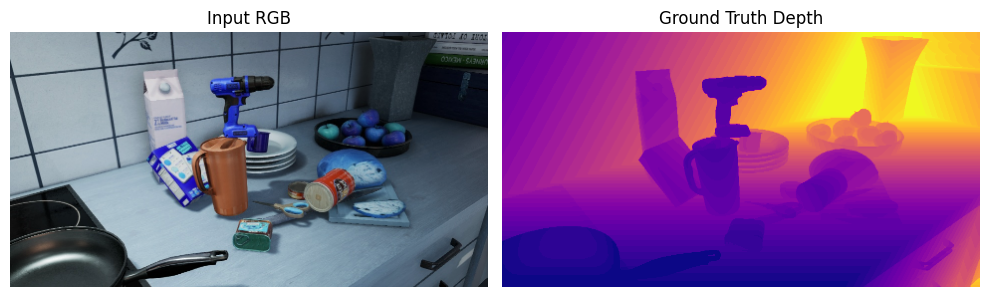

In [9]:
def list_left_samples(dataset_root: Path, max_samples: int = 2):
    left_images = sorted(dataset_root.rglob("*.left.jpg"))
    samples = []
    for left_img in left_images:
        depth_path = left_img.with_name(left_img.name.replace(".left.jpg", ".left.depth.png"))
        if depth_path.exists():
            samples.append({"kind": "dataset", "left_path": left_img, "depth_path": depth_path})
        if len(samples) >= max_samples:
            break
    if not samples:
        raise FileNotFoundError("No matching *.left.jpg + *.left.depth.png pairs found.")
    return samples


def load_depth_png(depth_path: Path) -> np.ndarray:
    return np.array(Image.open(depth_path)).astype(np.float32)


def load_npy_stack(path_or_array, name: str) -> np.ndarray:
    if path_or_array is None:
        raise ValueError(f"{name} is required when INPUT_MODE='npy_arrays'.")
    if isinstance(path_or_array, (str, Path)):
        arr = np.load(path_or_array)
    else:
        arr = np.asarray(path_or_array)
    if arr.ndim not in (3, 4):
        raise ValueError(f"{name} must have shape (N,H,W) or (N,H,W,C), got {arr.shape}.")
    return arr


def normalize_to_uint8(arr2d: np.ndarray) -> np.ndarray:
    arr2d = arr2d.astype(np.float32)
    amin = float(np.min(arr2d))
    amax = float(np.max(arr2d))
    if amax <= amin:
        return np.zeros(arr2d.shape, dtype=np.uint8)
    norm = (arr2d - amin) / (amax - amin)
    return np.clip(norm * 255.0, 0, 255).astype(np.uint8)


def left_array_to_pil(left: np.ndarray) -> Image.Image:
    if left.ndim == 2:
        img_u8 = normalize_to_uint8(left)
        rgb = np.stack([img_u8, img_u8, img_u8], axis=-1)
        return Image.fromarray(rgb, mode="RGB")

    if left.ndim == 3:
        if left.shape[-1] == 1:
            img_u8 = normalize_to_uint8(left[..., 0])
            rgb = np.stack([img_u8, img_u8, img_u8], axis=-1)
            return Image.fromarray(rgb, mode="RGB")
        if left.shape[-1] >= 3:
            rgb = left[..., :3]
            if np.issubdtype(rgb.dtype, np.floating):
                if float(np.max(rgb)) <= 1.0:
                    rgb = rgb * 255.0
                rgb = np.clip(rgb, 0, 255).astype(np.uint8)
            else:
                rgb = np.clip(rgb, 0, 255).astype(np.uint8)
            return Image.fromarray(rgb, mode="RGB")

    raise ValueError(f"Unsupported left image shape: {left.shape}")


def build_npy_samples(left_source, depth_source, right_source=None, max_samples: int = 2, start_index: int = 0):
    left_stack = load_npy_stack(left_source, "LEFT_NPY_PATH")
    depth_stack = load_npy_stack(depth_source, "DEPTH_NPY_PATH")

    if left_stack.shape[0] != depth_stack.shape[0]:
        raise ValueError(
            f"Mismatched sample count: left has {left_stack.shape[0]}, depth has {depth_stack.shape[0]}."
        )

    if right_source is not None:
        right_stack = load_npy_stack(right_source, "RIGHT_NPY_PATH")
        if right_stack.shape[0] != left_stack.shape[0]:
            raise ValueError(
                f"Mismatched sample count: right has {right_stack.shape[0]}, left has {left_stack.shape[0]}."
            )

    total = left_stack.shape[0]
    if start_index < 0:
        raise ValueError(f"start_index must be >= 0, got {start_index}.")
    if start_index >= total:
        raise ValueError(f"start_index={start_index} is out of range for {total} samples.")

    end_index = min(start_index + max_samples, total)

    samples = []
    for idx in range(start_index, end_index):
        samples.append(
            {
                "kind": "npy",
                "id": f"npy_{idx:04d}",
                "left": left_stack[idx],
                "depth": depth_stack[idx].astype(np.float32),
            }
        )

    if not samples:
        raise ValueError("No samples found in provided .npy arrays.")
    return samples


def load_sample(sample):
    if sample["kind"] == "dataset":
        rgb = Image.open(sample["left_path"]).convert("RGB")
        gt_depth = load_depth_png(sample["depth_path"])
        sample_name = str(sample["left_path"])
        subplot_title = sample["left_path"].parent.name
    else:
        rgb = left_array_to_pil(np.asarray(sample["left"]))
        gt_depth = np.asarray(sample["depth"], dtype=np.float32)
        sample_name = sample["id"]
        subplot_title = sample["id"]

    return rgb, gt_depth, sample_name, subplot_title


def robust_minmax(arr: np.ndarray, valid_mask: np.ndarray):
    if not np.any(valid_mask):
        return 0.0, 1.0
    vals = arr[valid_mask]
    vmin = np.percentile(vals, 2)
    vmax = np.percentile(vals, 98)
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return float(vmin), float(vmax)


if INPUT_MODE == "dataset_jpg":
    samples = list_left_samples(DATASET_ROOT, max_samples=NUM_SAMPLES)
else:
    samples = build_npy_samples(
        left_source=LEFT_NPY_PATH,
        right_source=RIGHT_NPY_PATH,
        depth_source=DEPTH_NPY_PATH,
        max_samples=NUM_SAMPLES,
        start_index=NPY_START_INDEX,
    )

print(f"Found {len(samples)} samples.")
for i, sample in enumerate(samples, 1):
    if sample["kind"] == "dataset":
        print(f"{i}. {sample['left_path'].name} | {sample['depth_path'].name}")
    else:
        left_shape = np.asarray(sample["left"]).shape
        depth_shape = np.asarray(sample["depth"]).shape
        print(f"{i}. {sample['id']} | left={left_shape}, depth={depth_shape}")

# Quick visual sanity check (appears before model loading)
rgb0, gt0, _, _ = load_sample(samples[0])
valid0 = gt0 > 0
vmin0, vmax0 = robust_minmax(gt0, valid0)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(rgb0)
ax[0].set_title("Input RGB")
ax[0].axis("off")
ax[1].imshow(gt0, cmap="plasma", vmin=vmin0, vmax=vmax0)
ax[1].set_title("Ground Truth Depth")
ax[1].axis("off")
plt.tight_layout()
plt.show()


In [10]:
models = {}
for name, model_id in MODEL_IDS.items():
    print(f"Loading {name} ({model_id})...")
    processor = AutoImageProcessor.from_pretrained(model_id)
    model = AutoModelForDepthEstimation.from_pretrained(model_id).to(device)
    model.eval()
    models[name] = (processor, model)
print(f"Loaded {len(models)} models: {list(models.keys())}")

Loading DPT-Large (Intel/dpt-large)...


Loading weights: 100%|██████████| 458/458 [00:00<00:00, 6558.99it/s]
[transformers] DPTForDepthEstimation LOAD REPORT from: Intel/dpt-large
Key                                                            | Status  | 
---------------------------------------------------------------+---------+-
neck.fusion_stage.layers.0.residual_layer1.convolution1.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading Depth-Anything-V2-Small (depth-anything/Depth-Anything-V2-Small-hf)...


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 8732.68it/s]


Loading ZoeDepth-NK (Intel/zoedepth-nyu-kitti)...


Loading weights: 100%|██████████| 647/647 [00:00<00:00, 2152.01it/s]

Loaded 3 models: ['DPT-Large', 'Depth-Anything-V2-Small', 'ZoeDepth-NK']


Running sample 1/2: npy_0357
Running sample 2/2: npy_0358


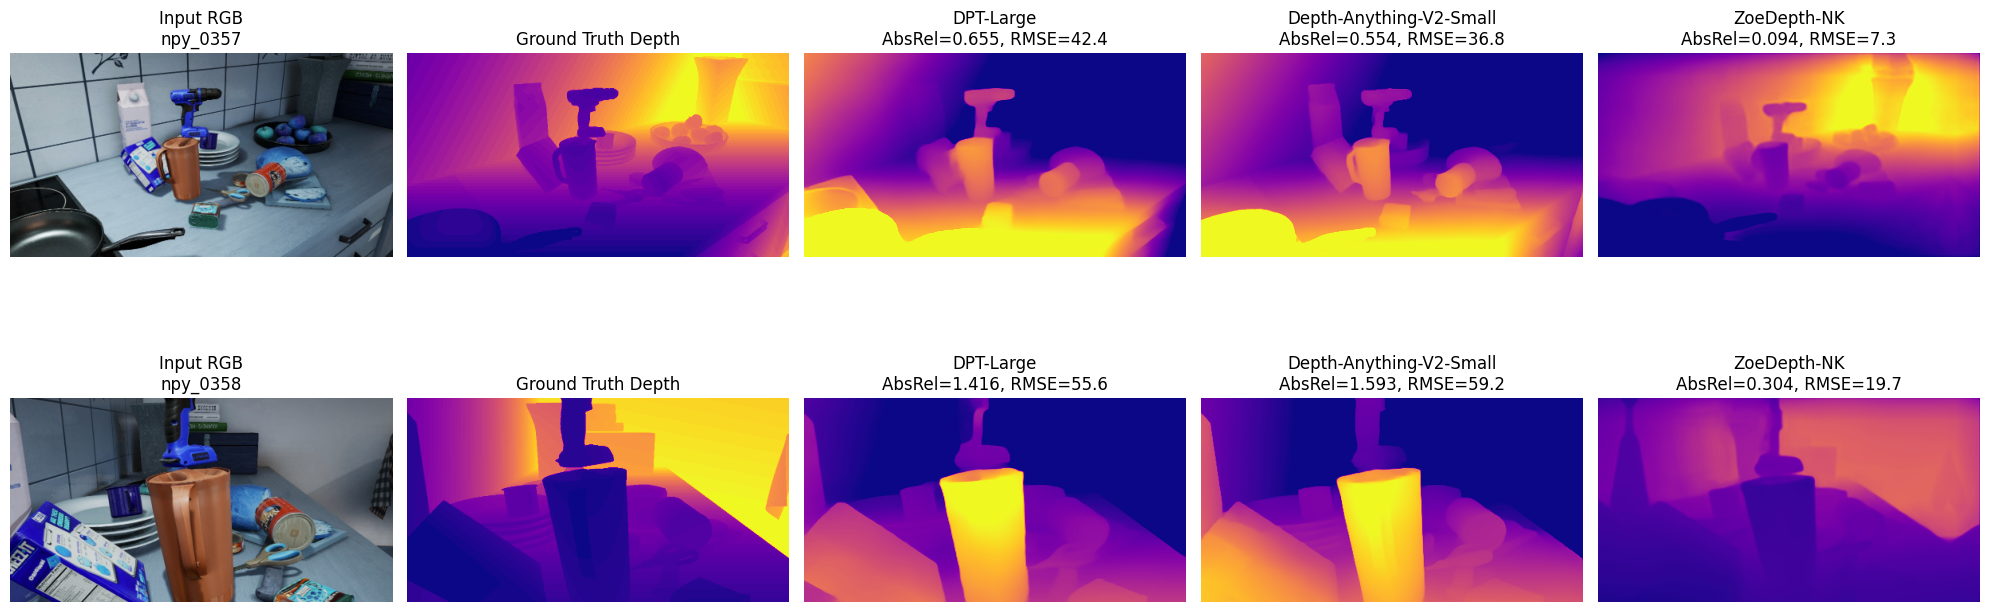

Saved comparison image to: /Users/ahmed_ali/Documents/GitHub/DeepView3D/visuals/sota_depth_comparison.png


In [11]:
def predict_depth(model_bundle, pil_image: Image.Image) -> np.ndarray:
    processor, model = model_bundle
    inputs = processor(images=pil_image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        pred = model(**inputs).predicted_depth
        pred = F.interpolate(
            pred.unsqueeze(1),
            size=pil_image.size[::-1],
            mode="bicubic",
            align_corners=False,
        ).squeeze().cpu().numpy().astype(np.float32)
    return pred


def scale_align_prediction(pred: np.ndarray, gt: np.ndarray, valid_mask: np.ndarray) -> np.ndarray:
    pred_valid = pred[valid_mask]
    gt_valid = gt[valid_mask]
    pred_med = np.median(pred_valid)
    gt_med = np.median(gt_valid)
    if pred_med <= 0:
        return pred
    return pred * (gt_med / pred_med)


def depth_metrics(pred: np.ndarray, gt: np.ndarray, valid_mask: np.ndarray):
    p = pred[valid_mask]
    g = gt[valid_mask]
    abs_rel = float(np.mean(np.abs(p - g) / np.clip(g, 1e-6, None)))
    rmse = float(np.sqrt(np.mean((p - g) ** 2)))
    return {"AbsRel": abs_rel, "RMSE": rmse}


all_rows = []
num_cols = 2 + len(models)
fig, axes = plt.subplots(len(samples), num_cols, figsize=(4 * num_cols, 4 * len(samples)))
if len(samples) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, sample in enumerate(samples):
    rgb, gt_depth, sample_name, subplot_title = load_sample(sample)
    print(f"Running sample {row_idx + 1}/{len(samples)}: {sample_name}")
    valid = gt_depth > 0
    gt_vmin, gt_vmax = robust_minmax(gt_depth, valid)

    axes[row_idx, 0].imshow(rgb)
    axes[row_idx, 0].set_title(f"Input RGB\n{subplot_title}")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(gt_depth, cmap="plasma", vmin=gt_vmin, vmax=gt_vmax)
    axes[row_idx, 1].set_title("Ground Truth Depth")
    axes[row_idx, 1].axis("off")

    for col_idx, (model_name, bundle) in enumerate(models.items(), start=2):
        pred = predict_depth(bundle, rgb)
        pred_aligned = scale_align_prediction(pred, gt_depth, valid)
        metrics = depth_metrics(pred_aligned, gt_depth, valid)
        all_rows.append({"sample": sample_name, "model": model_name, **metrics})

        axes[row_idx, col_idx].imshow(pred_aligned, cmap="plasma", vmin=gt_vmin, vmax=gt_vmax)
        axes[row_idx, col_idx].set_title(
            f"{model_name}\nAbsRel={metrics['AbsRel']:.3f}, RMSE={metrics['RMSE']:.1f}"
        )
        axes[row_idx, col_idx].axis("off")

plt.tight_layout()
out_path = OUTPUT_DIR / "sota_depth_comparison.png"
fig.savefig(out_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved comparison image to: {out_path.resolve()}")


In [12]:
results_df = pd.DataFrame(all_rows)
display(results_df)
summary = results_df.groupby("model")[["AbsRel", "RMSE"]].mean().sort_values("AbsRel")
display(summary)

csv_path = OUTPUT_DIR / "sota_depth_metrics.csv"
results_df.to_csv(csv_path, index=False)
print(f"Saved metrics to: {csv_path.resolve()}")

,sample,model,AbsRel,RMSE
0,npy_0357,DPT-Large,0.655395,42.435215
1,npy_0357,Depth-Anything-V2-Small,0.554499,36.811554
2,npy_0357,ZoeDepth-NK,0.094314,7.336602
3,npy_0358,DPT-Large,1.415962,55.602215
4,npy_0358,Depth-Anything-V2-Small,1.592740,59.216705
5,npy_0358,ZoeDepth-NK,0.303538,19.695192


,AbsRel,RMSE
model,,
ZoeDepth-NK,0.198926,13.515897
DPT-Large,1.035679,49.018715
Depth-Anything-V2-Small,1.073620,48.014130


Saved metrics to: /Users/ahmed_ali/Documents/GitHub/DeepView3D/visuals/sota_depth_metrics.csv
